In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from robotics_optimization_benchmarks.benchmarks.nl_opt import Himmelblau
from robotics_optimization_benchmarks.benchmarks.nl_opt import DoubleWell
from robotics_optimization_benchmarks.optimizers.gd import GD
from robotics_optimization_benchmarks.optimizers.mcmc import MCMC

colorblind_palette = [
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000",
]
cmap = ListedColormap(colorblind_palette)

(10000, 2)

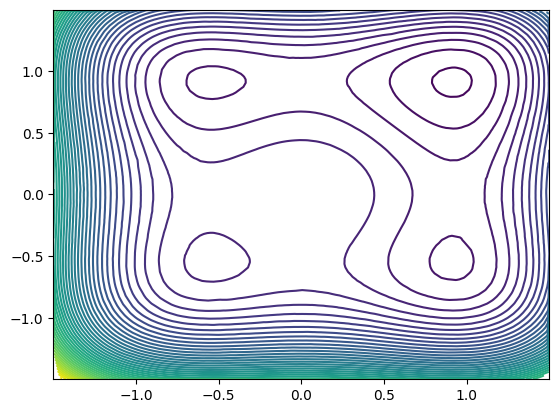

In [17]:
# Plot the countour values of the himmelblau function
f = DoubleWell(dimension=2)

key = jax.random.PRNGKey(0)
N = 10_000
keys = jax.random.split(key, N)
x = jax.vmap(f.sample_initial_guess)(keys) * 0.5
y = jax.vmap(f.evaluate_solution)(x)

plt.figure()
plt.tricontour(x[:, 0], x[:, 1], y, levels=50)

(10000, 2)

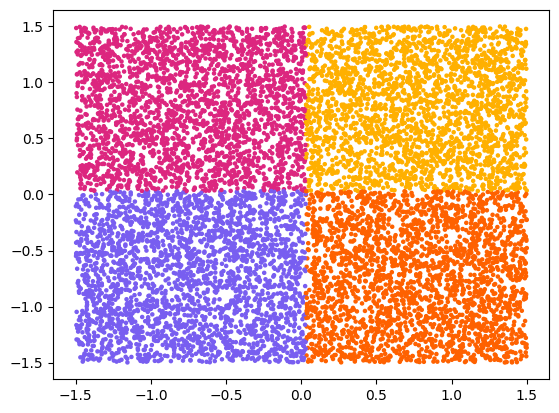

In [18]:
# Run gradient descent from each of these initial guesses for a bunch of steps
gd_opt = GD(step_size=1e-3)
steps = 1000

def gd_optimize_from_initial_guess(x):
    opt_state, step_fn = gd_opt.make_step(f.evaluate_solution, x)
    for _ in range(steps):
        opt_state = jax.jit(step_fn)(opt_state, key)
    return opt_state


opt_states = jax.vmap(gd_optimize_from_initial_guess)(x)

# Cluster states by which minimum they converged to
minima = jnp.array(
    [
        [-0.5, -0.5],
        [-0.5, 1.0],
        [1.0, -0.5],
        [1.0, 1.0],
    ]
)
final_states = opt_states.solution
distance_to_each_minima = jnp.linalg.norm(
    final_states[:, None, :] - minima[None, :, :], axis=-1
)
closest_minima = jnp.argmin(distance_to_each_minima, axis=-1)

# Plot initial states, colored by which minimum they converged to
plt.scatter(x[:, 0], x[:, 1], c=closest_minima, s=5, cmap=cmap)

(10000, 2)

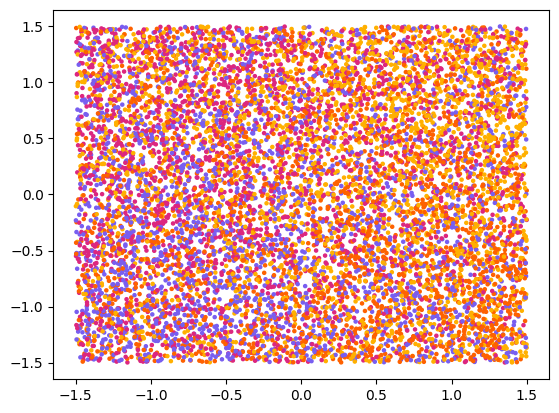

In [19]:
# Run mala from each of these initial guesses for a bunch of steps
mala_opt = MCMC(use_gradients=True, use_metropolis=True, step_size=1e-3, objective_scale=1e0)
steps = 1000

def mala_optimize_from_initial_guess(x, key):
    opt_state, step_fn = mala_opt.make_step(f.evaluate_solution, x)
    keys = jax.random.split(key, steps)
    xs = []
    solution_values = []
    for key in keys:
        opt_state = jax.jit(step_fn)(opt_state, key)
        xs.append(opt_state.solution)
        solution_values.append(opt_state.objective_value)
    return opt_state, jnp.stack(xs), jnp.stack(solution_values)

chain_keys = jax.random.split(key, N)
opt_states, xs, ys = jax.vmap(mala_optimize_from_initial_guess, in_axes=(0, 0))(x, chain_keys)

# Cluster states by which minimum they converged to
minima = jnp.array(
    [
        [-0.5, -0.5],
        [-0.5, 1.0],
        [1.0, -0.5],
        [1.0, 1.0],
    ]
)
final_states = opt_states.solution
distance_to_each_minima = jnp.linalg.norm(
    final_states[:, None, :] - minima[None, :, :], axis=-1
)
closest_minima = jnp.argmin(distance_to_each_minima, axis=-1)

# Plot initial states, colored by which minimum they converged to
plt.scatter(x[:, 0], x[:, 1], c=closest_minima, cmap=cmap, s=5)

plt.gcf().gca().get_xlim()

(10000, 2)

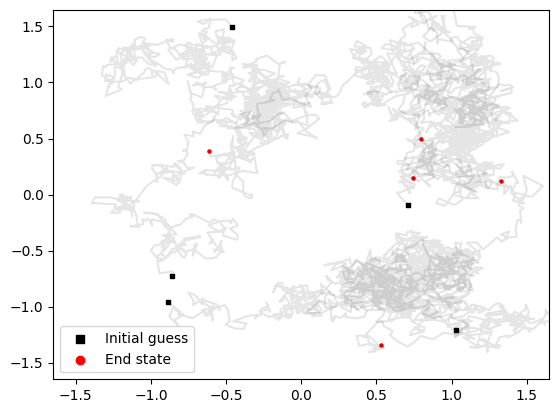

In [20]:
# Plot some chains
for i in range(5):
    plt.plot(xs[i, :, 0], xs[i, :, 1], c="black", alpha=0.1)
    plt.scatter(xs[i, 0, 0], xs[i, 0, 1], c="black", marker="s", s=5)
    plt.scatter(xs[i, -1, 0], xs[i, -1, 1], c="red", marker="o", s=5)

plt.scatter([], [], c="black", marker="s", label="Initial guess")
plt.scatter([], [], c="red", marker="o", label="End state")
plt.xlim(-1.6486801207065582, 1.6498277485370636)
plt.ylim(-1.6486801207065582, 1.6498277485370636)
plt.legend()

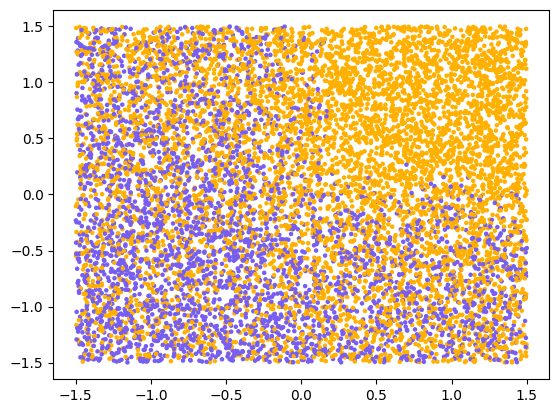

In [22]:
states = xs
distance_to_each_minima = jnp.linalg.norm(
    states[:, :, None, :] - minima[None, None, :, :], axis=-1
)
closest_minima = jnp.argmin(distance_to_each_minima, axis=-1)
ever_closest_to_global_minimum = jnp.any(closest_minima == 3, axis=1)
plt.scatter(x[:, 0], x[:, 1], c=ever_closest_to_global_minimum, cmap=cmap, s=5)

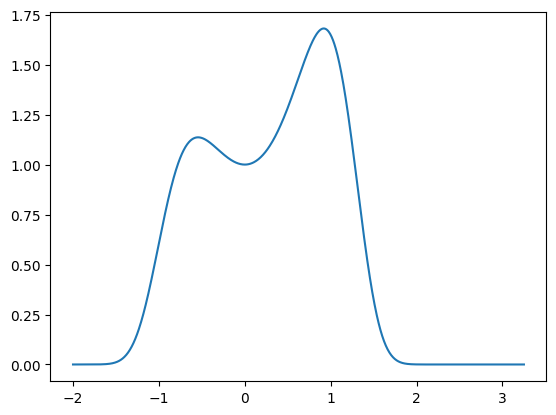

In [6]:
def U(x):
    return (x**4 - x**2 - 0.5 * x**3).sum(axis=-1)

def p(x):
    return jnp.exp(-U(x))

# Make a plot of this cost function
x = jnp.linspace(-2, 3.25, 1000).reshape(-1, 1)
y = U(x)
p = p(x)
plt.figure()
plt.plot(x, p)
